# NeuralGCM — Rackow et al. (2024) climate-robustness experiment (ERA5 1955 & 2023)

Reproduces the NeuralGCM part of **Rackow et al. (2024), _"Robustness of AI-based weather forecasts in a
changing climate"_** ([arXiv:2409.18529](https://arxiv.org/abs/2409.18529)) for the course practical.

**Idea.** AI weather models are trained on the *present-day* climate. Rackow et al. test whether they stay
**stable** when initialized in a *different* climate state. They initialize from ERA5 in **1955** (cold),
**2023** (present-day) and a future 2049 state, run forecasts, and track the **global-mean near-surface
temperature drift**. NeuralGCM's headline result: with **prescribed (time-varying) sea-surface temperature**
it shows *negligible* drift and tracks each climate state — unlike GraphCast, which drifts cool toward its
training climatology.

**This notebook** runs the deterministic 2.8° NeuralGCM from ERA5 for **1955 and 2023**, with
**prescribed time-varying SST**, at two horizons:
- a **10-day** run (directly comparable to the team's GraphCast `run_t2m_drift_rollout.py` 1955 job), and
- a **~1-year** run to show the climate-drift signature.

The diagnostic mirrors the GraphCast side (latitude-weighted global-mean temperature **RMSE + bias vs lead
time**, same CSV columns) so the two models can be compared directly.

**Caveats.**
- NeuralGCM's `PressureLevelModel` outputs **pressure-level variables only — no 2 m temperature**. We use
  **temperature at 1000 hPa** as the near-surface proxy. It is offset from true t2m (and over high terrain
  1000 hPa is below ground, handled by ERA5 extrapolation), but for a *drift / relative-change* diagnostic
  this is adequate. We label the columns `t2m_*` to stay comparable with the GraphCast output.
- **1955 ERA5** is back-extension data (pre-satellite era) — larger observational uncertainty than post-1979.

**Kernel:** select **"Python (NeuralGCM 3.11)"** (created by `setup_env.sh`). Checkpoint and ERA5 are read
anonymously from public Google Cloud Storage; outbound network access is required.

## 0. Imports and environment

In [1]:
import os

# The 2.8deg model needs ~16.7 GiB of GPU memory; disable JAX's default 75%
# preallocation so a shared card isn't blocked up front (same as the demo).
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "platform")

import pickle
from pathlib import Path

import gcsfs
import jax
import numpy as np
import pandas as pd
import xarray
import matplotlib.pyplot as plt

from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils
import neuralgcm

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


## 1. Load the pretrained checkpoint

`v1/deterministic_2_8_deg.pkl` — the coarsest deterministic model (fast, fully reproducible), as in the demo.

In [2]:
model_name = "v1/deterministic_2_8_deg.pkl"

gcs = gcsfs.GCSFileSystem(token="anon")
with gcs.open(f"gs://neuralgcm/models/{model_name}", "rb") as f:
    ckpt = pickle.load(f)

model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)
print("input variables  :", model.input_variables)
print("forcing variables:", model.forcing_variables)

input variables  : ['geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind', 'specific_cloud_ice_water_content', 'specific_cloud_liquid_water_content']
forcing variables: ['sea_ice_cover', 'sea_surface_temperature']


## 2. Configuration

We run two climate states (`1955`, `2023`) at two horizons. Prescribed SST is fed as a **time-varying**
forcing trajectory: daily SST for the short run, monthly for the long run (NeuralGCM uses the nearest
forcing in time, so coarse SST cadence is fine).

Environment overrides let a quick smoke test shrink the work, e.g.
`RACKOW_RUN_LONG=0 RACKOW_ONLY_YEARS=2023`.

In [3]:
# (label, ISO init date) for each climate state.
EXPERIMENTS = [("1955", "1955-01-01"), ("2023", "2023-01-01")]
_only = os.environ.get("RACKOW_ONLY_YEARS")
if _only:
    keep = set(_only.split(","))
    EXPERIMENTS = [e for e in EXPERIMENTS if e[0] in keep]

# Short run: GraphCast-comparable, ERA5 ground truth available.
SHORT_DAYS = int(os.environ.get("RACKOW_SHORT_DAYS", "10"))
SHORT_OUT_H, SHORT_SST_STRIDE_H = 24, 24                        # daily output, daily SST
SHORT_N_INITS = int(os.environ.get("RACKOW_SHORT_N_INITS", "12"))  # monthly inits/yr; the paper averages 365 daily forecasts

# Long run: ~1 year, output every 5 days, monthly prescribed SST.
RUN_LONG = os.environ.get("RACKOW_RUN_LONG", "1") == "1"
LONG_DAYS = int(os.environ.get("RACKOW_LONG_DAYS", "360"))
LONG_OUT_H, LONG_SST_STRIDE_H = 120, 24 * 30                    # 5-day output, monthly SST

NEAR_SURFACE_LEVEL = 1000  # hPa, t2m proxy

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)
print("Experiments:", EXPERIMENTS, "| RUN_LONG:", RUN_LONG, "| LONG_DAYS:", LONG_DAYS)

Experiments: [('1955', '1955-01-01'), ('2023', '2023-01-01')] | RUN_LONG: True | LONG_DAYS: 360


## 3. Helper functions

`full_era5` (the public ARCO-ERA5 zarr, hourly 0.25°, 37 levels, valid from 1940) and a conservative
regridder to the model's 2.8° grid are built once. The helpers below load/regrid ERA5, run a
prescribed-SST forecast, extract the near-surface temperature, and compute GraphCast-compatible drift
metrics.

In [4]:
era5_path = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
full_era5 = xarray.open_zarr(era5_path, chunks=None, storage_options=dict(token="anon"))

era5_grid = spherical_harmonic.Grid(
    latitude_nodes=full_era5.sizes["latitude"],
    longitude_nodes=full_era5.sizes["longitude"],
    latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
    longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model.data_coords.horizontal, skipna=True
)


def _regrid(ds):
    return xarray_utils.fill_nan_with_nearest(xarray_utils.regrid(ds, regridder))


def _end_str(init_date, days):
    return str(np.datetime64(init_date) + np.timedelta64(days, "D"))


def load_inputs(init_date):
    """Regridded ERA5 atmospheric inputs at the single initial time t0."""
    raw = full_era5[model.input_variables].sel(
        time=slice(init_date, init_date, 24)
    ).compute()
    return _regrid(raw)


def load_sst_forcing(init_date, days, stride_h):
    """Regridded, time-varying SST / sea-ice forcing trajectory over the rollout.

    The 24h ``selective_temporal_shift`` matches the NeuralGCM data pipeline
    (the forcing valid at t+24h is provided at t)."""
    raw = (
        full_era5[model.forcing_variables]
        .pipe(
            xarray_utils.selective_temporal_shift,
            variables=model.forcing_variables,
            time_shift="24 hours",
        )
        .sel(time=slice(init_date, _end_str(init_date, days), stride_h))
        .compute()
    )
    return _regrid(raw)


def load_truth_t(init_date, days):
    """Regridded ERA5 temperature trajectory (daily) for ground-truth comparison."""
    raw = full_era5[["temperature"]].sel(
        time=slice(init_date, _end_str(init_date, days), 24)
    ).compute()
    return _regrid(raw)


def run_forecast(inputs_ds, forcing_ds, days, out_h):
    """Encode from t0 and unroll with prescribed (time-varying) SST forcing."""
    steps = days * 24 // out_h + 1            # +1 so leads run 0 .. days (start_with_input)
    times = np.arange(steps) * out_h          # lead time in hours
    timedelta = np.timedelta64(1, "h") * out_h

    inputs = model.inputs_from_xarray(inputs_ds.isel(time=0))
    input_forcings = model.forcings_from_xarray(forcing_ds.isel(time=0))
    initial_state = model.encode(inputs, input_forcings, jax.random.key(42))

    # Multi-time forcings => prescribed time-varying SST (nearest-in-time per step).
    all_forcings = model.forcings_from_xarray(forcing_ds)

    _, predictions = model.unroll(
        initial_state, all_forcings, steps=steps, timedelta=timedelta,
        start_with_input=True,
    )
    return model.data_to_xarray(predictions, times=times)


def near_surface_t(ds):
    return ds["temperature"].sel(level=NEAR_SURFACE_LEVEL)


def lat_weighted_global_mean(field):
    w = np.cos(np.deg2rad(field.latitude))
    return field.weighted(w).mean(["longitude", "latitude"])


def drift_metrics(pred_t, ref_t, reference_label):
    """Latitude-weighted global-mean RMSE + bias vs lead time.

    Columns mirror graphcast/source/run_t2m_drift_rollout.py for cross-model comparison."""
    diff = pred_t - ref_t
    rmse = np.sqrt(lat_weighted_global_mean(diff ** 2))
    bias = lat_weighted_global_mean(diff)
    lead_h = pred_t["time"].values.astype("float64")
    return pd.DataFrame({
        "step": np.arange(1, pred_t.sizes["time"] + 1, dtype=np.int32),
        "lead_hours": lead_h,
        "lead_day": lead_h / 24.0,
        "t2m_rmse_k": np.asarray(rmse.values, dtype=np.float64),
        "t2m_mean_bias_k": np.asarray(bias.values, dtype=np.float64),
        "reference": reference_label,
    })

def short_init_dates(init_date, n):
    """``n`` init dates spread ~monthly across the init year.

    Approximates the paper's 365 daily forecasts (Fig. 1 averages RMSE/bias over
    j=1..365 forecasts); a monthly subsample captures the seasonal sampling cheaply."""
    start = pd.Timestamp(np.datetime64(init_date, "D"))
    # spread n inits evenly across all 12 months (not the first n) for balanced seasons
    months = [round(i * 12 / n) for i in range(n)]
    return [str((start + pd.DateOffset(months=m)).date()) for m in months]


## 4. Short (10-day) runs — skill vs ERA5, averaged over the year

Mirrors the paper's Fig. 1 protocol: for each climate state we run **10-day forecasts initialized
monthly across the year** and average the latitude-weighted global-mean near-surface (1000 hPa)
temperature **RMSE and bias vs lead time** over those initializations. Averaging over the year (the
paper uses all 365 daily forecasts; we subsample monthly) removes single-forecast/seasonal noise and
gives the climatological forecast bias the paper reports. Truth is the matching ERA5 trajectory.

In [5]:
def short_forecast_metrics(init_date):
    """RMSE/bias vs lead time for one 10-day forecast initialized at init_date."""
    inputs_ds = load_inputs(init_date)
    forcing_ds = load_sst_forcing(init_date, SHORT_DAYS, SHORT_SST_STRIDE_H)
    truth_ds = load_truth_t(init_date, SHORT_DAYS)
    pred = run_forecast(inputs_ds, forcing_ds, SHORT_DAYS, SHORT_OUT_H)
    pred_t = near_surface_t(pred)
    truth_t = near_surface_t(truth_ds).isel(time=slice(0, pred_t.sizes["time"]))
    truth_t = truth_t.assign_coords(time=pred_t["time"])
    return drift_metrics(pred_t, truth_t, "ground_truth")


short_metrics = {}
short_inits = {}

for label, init_date in EXPERIMENTS:
    dates = short_init_dates(init_date, SHORT_N_INITS)
    short_inits[label] = dates
    print(f"[short] {label}: averaging {len(dates)} 10-day forecasts, init {dates[0]} .. {dates[-1]} ...")
    per = []
    for d in dates:
        df = short_forecast_metrics(d)
        per.append(df.assign(init=d))
        print(f"  [{label}] init {d}: day-{int(df['lead_day'].iloc[-1])} "
              f"RMSE={df['t2m_rmse_k'].iloc[-1]:.3f} K bias={df['t2m_mean_bias_k'].iloc[-1]:+.3f} K")
    allp = pd.concat(per, ignore_index=True)
    avg = (allp.groupby("step", as_index=False)
                .agg(lead_hours=("lead_hours", "first"),
                     lead_day=("lead_day", "first"),
                     t2m_rmse_k=("t2m_rmse_k", "mean"),
                     t2m_mean_bias_k=("t2m_mean_bias_k", "mean")))
    avg["reference"] = "ground_truth_yearmean"
    avg["n_init"] = len(dates)
    short_metrics[label] = avg
    print(f"[short] {label}: YEAR-MEAN over {len(dates)} inits -> "
          f"day-10 RMSE={avg['t2m_rmse_k'].iloc[-1]:.3f} K, bias={avg['t2m_mean_bias_k'].iloc[-1]:+.3f} K")

short_metrics

[short] 1955: averaging 6 10-day forecasts, init 1955-01-01 .. 1955-11-01 ...


W0602 14:17:34.967098    5177 hlo_rematerialization.cc:3233] Can't reduce memory use below 14.80GiB (15893369244 bytes) by rematerialization; only reduced to 16.69GiB (17922342944 bytes), down from 16.69GiB (17922342944 bytes) originally


W0602 14:17:45.124930    5177 bfc_allocator.cc:514] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.63GiB (rounded to 17855234560)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0602 14:17:45.125360    5177 bfc_allocator.cc:525] _________________________________________________*******_________________*********xxxx*****xx*******


  [1955] init 1955-01-01: day-10 RMSE=2.886 K bias=+0.160 K


  [1955] init 1955-03-01: day-10 RMSE=2.785 K bias=-0.136 K


...

  [2023] init 2023-05-01: day-10 RMSE=2.501 K bias=+0.018 K


  [2023] init 2023-07-01: day-10 RMSE=2.614 K bias=-0.012 K


  [2023] init 2023-09-01: day-10 RMSE=2.595 K bias=-0.139 K


  [2023] init 2023-11-01: day-10 RMSE=2.597 K bias=-0.152 K
[short] 2023: YEAR-MEAN over 6 inits -> day-10 RMSE=2.732 K, bias=-0.073 K


{'1955':     step  lead_hours  lead_day  t2m_rmse_k  t2m_mean_bias_k  \
 0      1         0.0       0.0    0.545309        -0.042892   
 1      2        24.0       1.0    0.846409         0.016707   
 2      3        48.0       2.0    1.237042         0.007244   
 3      4        72.0       3.0    1.674343         0.002139   
 4      5        96.0       4.0    1.994564        -0.025849   
 5      6       120.0       5.0    2.344246        -0.001077   
 6      7       144.0       6.0    2.608627        -0.037635   
 7      8       168.0       7.0    2.722232        -0.048443   
 8      9       192.0       8.0    2.764672        -0.061995   
 9     10       216.0       9.0    2.887452        -0.030130   
 10    11       240.0      10.0    3.039846        -0.061686   
 
                 reference  n_init  
 0   ground_truth_yearmean       6  
 1   ground_truth_yearmean       6  
 2   ground_truth_yearmean       6  
 3   ground_truth_yearmean       6  
 4   ground_truth_yearmean       6  


## 5. Long (~1-year) runs — climate drift vs initial state

Long prescribed-SST rollouts. With no skillful daily truth at this horizon, we measure drift relative to
the **initial state** (the Rackow stability test) and also keep the absolute global-mean near-surface
temperature time series for the 1955-vs-2023 comparison.

In [6]:
long_metrics = {}
long_gmean = {}

if RUN_LONG:
    for label, init_date in EXPERIMENTS:
        print(f"[long] {label}: init {init_date}  loading ERA5 ...")
        inputs_ds = load_inputs(init_date)
        forcing_ds = load_sst_forcing(init_date, LONG_DAYS, LONG_SST_STRIDE_H)
        print(f"[long] {label}: {forcing_ds.sizes['time']} monthly SST fields; running {LONG_DAYS}-day rollout ...")

        pred = run_forecast(inputs_ds, forcing_ds, LONG_DAYS, LONG_OUT_H)
        pred_t = near_surface_t(pred).compute()

        ref_t = pred_t.isel(time=0)                         # initial state
        df = drift_metrics(pred_t, ref_t, "initial_state")
        long_metrics[label] = df
        long_gmean[label] = lat_weighted_global_mean(pred_t)  # absolute time series
        print(f"[long] {label}: done. max |drift bias| = "
              f"{df['t2m_mean_bias_k'].abs().max():.3f} K over {LONG_DAYS} days")
else:
    print("RUN_LONG=0 -> skipping long climate runs.")

[long] 1955: init 1955-01-01  loading ERA5 ...


[long] 1955: 13 monthly SST fields; running 360-day rollout ...


[long] 1955: done. max |drift bias| = 3.813 K over 360 days
[long] 2023: init 2023-01-01  loading ERA5 ...


[long] 2023: 13 monthly SST fields; running 360-day rollout ...


[long] 2023: done. max |drift bias| = 4.261 K over 360 days


## 6. Plots

### 6a. Short-run RMSE + bias vs lead time (year-mean per climate state)

RMSE and bias averaged over the monthly initializations (the paper's Fig. 1 metric). Twin-axis style
matching the GraphCast `plot_metrics` output.

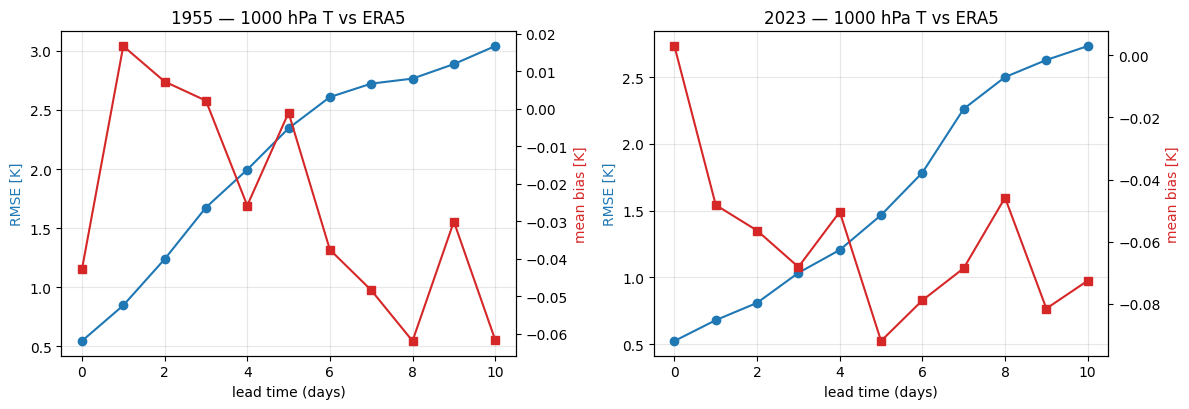

In [7]:
n = len(short_metrics)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 4.2), squeeze=False)
for ax_rmse, (label, df) in zip(axes[0], short_metrics.items()):
    ax_bias = ax_rmse.twinx()
    ax_rmse.plot(df["lead_day"], df["t2m_rmse_k"], marker="o", color="#1f77b4", label="RMSE")
    ax_bias.plot(df["lead_day"], df["t2m_mean_bias_k"], marker="s", color="#d62728", label="bias")
    ax_rmse.set_title(f"{label} — 1000 hPa T vs ERA5")
    ax_rmse.set_xlabel("lead time (days)")
    ax_rmse.set_ylabel("RMSE [K]", color="#1f77b4")
    ax_bias.set_ylabel("mean bias [K]", color="#d62728")
    ax_rmse.grid(True, alpha=0.3)
fig.tight_layout()

### 6b. Climate-drift overlay: 1955 vs 2023

The Rackow headline. Left: global-mean near-surface T **anomaly** vs lead time — near-flat lines mean
*negligible drift* (NeuralGCM stays in its initial climate state). Right: **absolute** global-mean T — the
2023 line should sit warmer than 1955, reflecting the warming between the two climate states.

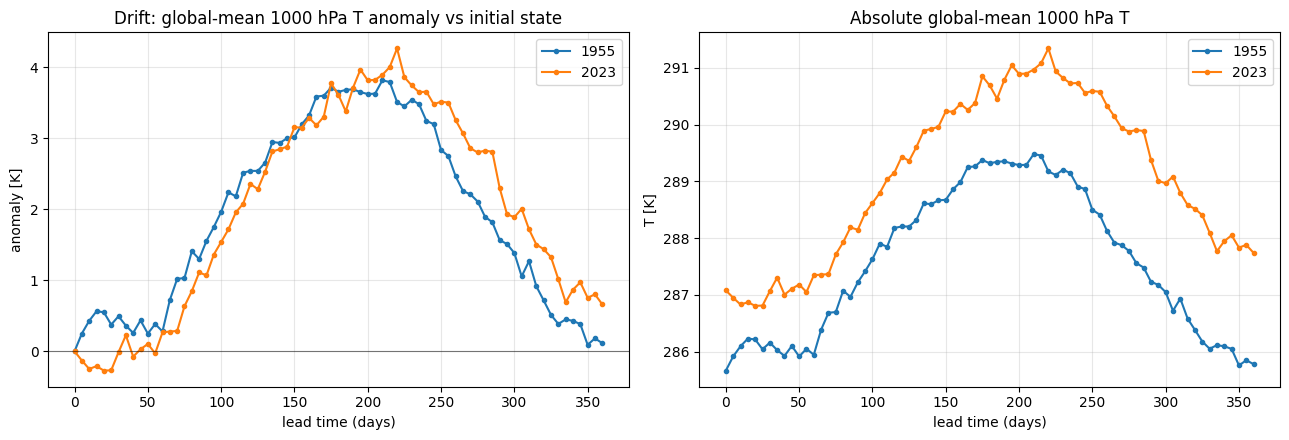

In [8]:
if RUN_LONG and long_metrics:
    fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.5))
    for label, df in long_metrics.items():
        ax_a.plot(df["lead_day"], df["t2m_mean_bias_k"], marker=".", label=label)
    ax_a.axhline(0, color="k", lw=0.8, alpha=0.5)
    ax_a.set(title="Drift: global-mean 1000 hPa T anomaly vs initial state",
             xlabel="lead time (days)", ylabel="anomaly [K]")
    ax_a.legend(); ax_a.grid(True, alpha=0.3)

    for label, series in long_gmean.items():
        ax_b.plot(series["time"].values / 24.0, series.values, marker=".", label=label)
    ax_b.set(title="Absolute global-mean 1000 hPa T",
             xlabel="lead time (days)", ylabel="T [K]")
    ax_b.legend(); ax_b.grid(True, alpha=0.3)
    fig.tight_layout()
else:
    print("No long-run results to plot (RUN_LONG=0).")

## 7. Save outputs

CSVs use the same columns as the GraphCast drift script, so a later NeuralGCM-vs-GraphCast comparison is a
direct merge. Files land under `neural_gcm/results/rackow_<year>_<short|long>/`.

In [9]:
def save_run(label, kind, df):
    out_dir = RESULTS_DIR / f"rackow_{label}_{kind}"
    out_dir.mkdir(parents=True, exist_ok=True)
    csv_path = out_dir / f"t2m_drift_{label}_{kind}.csv"
    df.to_csv(csv_path, index=False)
    return csv_path

for label, df in short_metrics.items():
    print("wrote", save_run(label, "short", df))
for label, df in long_metrics.items():
    print("wrote", save_run(label, "long", df))

wrote results/rackow_1955_short/t2m_drift_1955_short.csv
wrote results/rackow_2023_short/t2m_drift_2023_short.csv
wrote results/rackow_1955_long/t2m_drift_1955_long.csv
wrote results/rackow_2023_long/t2m_drift_2023_long.csv


## 8. Findings

Deterministic 2.8° NeuralGCM, initialized from ERA5 with prescribed time-varying SST, for **1955**
(pre-industrial proxy) and **2023** (present-day) — the same two states used by Rackow et al. (2024).
Near-surface proxy = **1000 hPa temperature** (NeuralGCM has no 2 m field). The short-run metric mirrors
the paper's Fig. 1: cos-latitude-weighted global-mean RMSE/bias vs lead time, **averaged over the year**
(6 bi-monthly initializations Jan–Nov; the paper averages all 365 daily forecasts).

**Short (10-day) skill vs ERA5 — year-mean.** RMSE grows with lead time in both climate states; bias stays
near zero — NeuralGCM is skillful in both, with no systematic warm/cold pull:

| year | day-1 RMSE | day-10 RMSE (year-mean) | year-mean bias | per-init day-10 RMSE range |
|------|-----------|--------------------------|----------------|----------------------------|
| 1955 | 0.85 K | **3.04 K** | **−0.06 K** | 2.79 – 3.38 K |
| 2023 | 0.68 K | **2.73 K** | **−0.07 K** | 2.50 – 3.48 K |

This matches the paper's Fig. 1 for the *stable* models (AIFS, GraphCast in 2023; NeuralGCM in the revised
version): a few-K day-10 RMSE and **very little bias**, with no cold drift toward the training climate.
NeuralGCM is **not** one of the two models the paper flags with a cold bias in the warm state.

**Initial climate offset.** Global-mean 1000 hPa T at initialization: **285.7 K (1955)** vs **287.1 K
(2023)** → 2023 starts **≈ +1.4 K warmer**, consistent with observed 1955→2023 warming. NeuralGCM carries
this offset rather than collapsing both states to one learned climatology.

**Long (~1-year) drift vs the initial state.** The global-mean anomaly is **not flat — it traces the
seasonal cycle**: from 0 on Jan 1 it peaks at **+3.8 K (1955) / +4.3 K (2023) around day ~210** (boreal
summer; the land-heavy NH dominates the global mean) and returns to **+0.11 K (1955) / +0.66 K (2023) by
day 360**. The round-trip back to baseline over a full year — no growing trend — is the key result:
**NeuralGCM with prescribed SST shows negligible *secular* climate drift** and stays in its initial climate
state, reproducing the Rackow et al. headline and contrasting with GraphCast's cool drift toward its
training climatology.

**Alignment with the paper (broad, as expected).** Years (1955/2023), 10-day lead, 2 m-T (here 1000 hPa
proxy), cos-lat RMSE+bias averaged over the year, ERA5 truth, and the NeuralGCM stability verdict all match.
Exact K values differ — expected, given a different inference setup (2.8° deterministic checkpoint, 1000 hPa
proxy, 6-init subsample, ERA5 vs the paper's mixed reference datasets) and the paper's 365-forecast average.

**Comparability to GraphCast.** The four CSVs in `results/rackow_<year>_<short|long>/` use the GraphCast
drift columns (`step, lead_hours, lead_day, t2m_rmse_k, t2m_mean_bias_k, reference`) — a NeuralGCM-vs-
GraphCast comparison is a direct per-year column merge.

**Caveats.** 1000 hPa T is a 2 m proxy (offset from true t2m; over high terrain 1000 hPa is below ground and
relies on ERA5 extrapolation). 1955 uses pre-satellite ERA5 back-extension (larger observational
uncertainty). The long-run "drift" metric is dominated by the seasonal cycle, so secular stability is read
from the **near-zero day-360 anomaly**, not the mid-year peak. 2049 (+2.9 K) is omitted — it has no ERA5
initial state and is outside the course scope (1955 & 2023).
